<a href="https://colab.research.google.com/github/Cado87/Monai_projects/blob/main/Visualizer_nifti_dicom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup
First, we need to install the required libraries: MONAI (with all its dependencies like `pydicom` and `nibabel`), `tqdm` for progress bars, and `matplotlib` for plotting.

In [1]:
!pip install -q "monai[all]" "tqdm" "matplotlib"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5

Next, we'll import the necessary modules from `monai`, `pydicom`, `nibabel`, `matplotlib`, and `numpy`.

In [2]:
import os
import tempfile
import matplotlib.pyplot as plt
import numpy as np

import pydicom
import nibabel as nib

from monai.transforms import LoadImage, Orientation, ScaleIntensityRange, Resize, Compose
from monai.data import decollate_batch
from monai.visualize import plot_2d_or_3d_image
from monai.utils import first

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## Download Sample NIfTI Dataset
We'll download a small brain MRI dataset (BraTS 2018) from MONAI's public resources to use as real NIfTI data. This involves using `gdown` to download a zipped file and then extracting its contents.

In [3]:
from monai.apps import download_and_extract
import os
import shutil
import tempfile # Import tempfile for creating temporary directory

# Define data_dir at the beginning of the cell
data_dir = tempfile.mkdtemp()

# Define the resource URL for Task09_Spleen.tar
resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar"

# Ensure clean extraction by removing existing directory if it exists
extracted_target_dir = os.path.join(data_dir, "Task09_Spleen")
if os.path.exists(extracted_target_dir):
    print(f"Removing existing directory: {extracted_target_dir}")
    shutil.rmtree(extracted_target_dir)

print(f"Downloading and extracting Task09_Spleen dataset to: {data_dir}")
# download_and_extract handles creation of subdirectories
# It will extract to data_dir/Task09_Spleen/
download_and_extract(resource, output_dir=data_dir, file_type="tar")
print("Dataset downloaded and extracted.")

# --- Debugging: Inspect extracted contents ---
print(f"Contents of {data_dir}: {os.listdir(data_dir)}")

# After extraction, Task09_Spleen should exist
if os.path.exists(extracted_target_dir):
    print(f"Contents of {extracted_target_dir}: {os.listdir(extracted_target_dir)}")
    images_tr_dir = os.path.join(extracted_target_dir, "imagesTr")
    if os.path.exists(images_tr_dir):
        # Filter out AppleDouble files (starting with '._')
        actual_nifti_files = [f for f in os.listdir(images_tr_dir) if f.endswith('.nii.gz') and not f.startswith('._')]
        if actual_nifti_files:
            print(f"Actual NIfTI files found in {images_tr_dir}: {actual_nifti_files[:5]}...")
            # Pick the first actual NIfTI file found
            real_nifti_filepath = os.path.join(images_tr_dir, actual_nifti_files[0])

            # Update nifti_filepath to point to a real image from the downloaded dataset
            global nifti_filepath
            nifti_filepath = real_nifti_filepath
            print(f"Updated NIfTI filepath to real data: {nifti_filepath}")
        else:
            print(f"No .nii.gz files found in {images_tr_dir} after filtering. Keeping dummy NIfTI filepath.")
            real_nifti_filepath = None # Indicate it wasn't found
    else:
        print(f"Directory {images_tr_dir} does not exist. Keeping dummy NIfTI filepath.")
        real_nifti_filepath = None
else:
    print(f"Directory {extracted_target_dir} does not exist after download. Keeping dummy NIfTI filepath.")
    real_nifti_filepath = None

# If real_nifti_filepath was not updated, keep the dummy one
if real_nifti_filepath is None:
    print("Keeping the dummy NIfTI filepath for now.")

Task09_Spleen.tar: 1.50GB [00:39, 40.5MB/s]                            

2026-05-28 18:51:16,364 - INFO - Downloaded: /tmp/tmp5d0xixwb/Task09_Spleen.tar
2026-05-28 18:51:16,364 - INFO - Expected md5 is None, skip md5 check for file /tmp/tmp5d0xixwb/Task09_Spleen.tar.
2026-05-28 18:51:16,365 - INFO - Writing into directory: /tmp/tmpyzffin_p.


Dataset downloaded and extracted.
Contents of /tmp/tmpyzffin_p: ['._Task09_Spleen', 'Task09_Spleen']
Contents of /tmp/tmpyzffin_p/Task09_Spleen: ['labelsTr', '._dataset.json', '._imagesTr', '._imagesTs', 'imagesTs', 'imagesTr', 'dataset.json', '._labelsTr']
Actual NIfTI files found in /tmp/tmpyzffin_p/Task09_Spleen/imagesTr: ['spleen_27.nii.gz', 'spleen_56.nii.gz', 'spleen_49.nii.gz', 'spleen_18.nii.gz', 'spleen_6.nii.gz']...
Updated NIfTI filepath to real data: /tmp/tmpyzffin_p/Task09_Spleen/imagesTr/spleen_27.nii.gz


## NIfTI File Visualization
We'll use MONAI's `LoadImage` to load the NIfTI file and then `matplotlib` and `plot_2d_or_3d_image` for visualization.

NIfTI image shape: torch.Size([512, 512, 119])


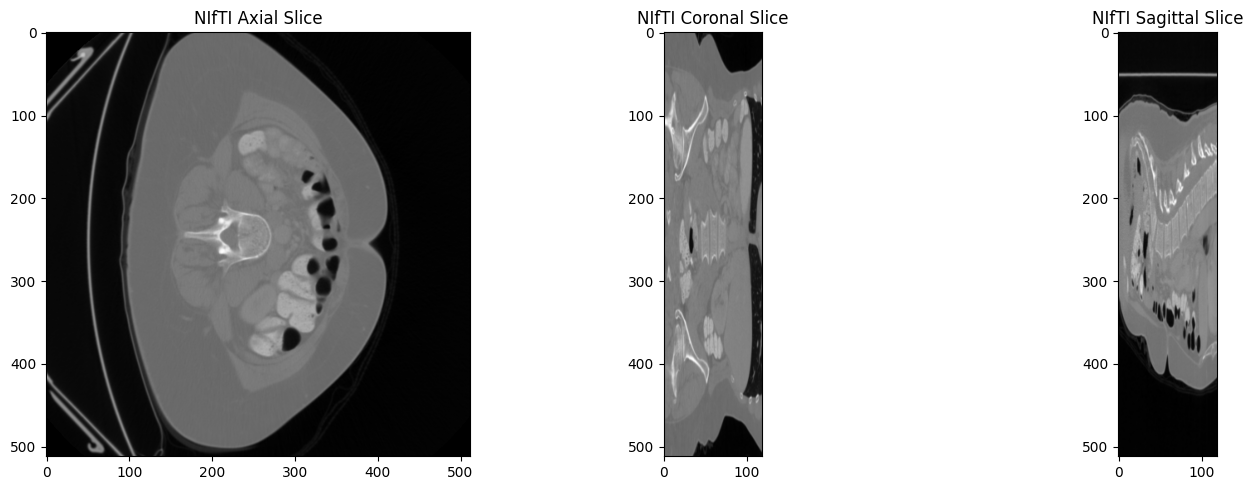

In [4]:
# Load NIfTI file
nifti_loader = LoadImage(image_only=True)
nifti_image = nifti_loader(nifti_filepath)
print(f"NIfTI image shape: {nifti_image.shape}")

# Visualize NIfTI image (middle slice) using matplotlib for axial, coronal, and sagittal views
plt.figure("NIfTI Visualization", (15, 5))
plt.subplot(1, 3, 1)
plt.title("NIfTI Axial Slice")
plt.imshow(nifti_image[..., nifti_image.shape[-1] // 2], cmap="gray")
plt.subplot(1, 3, 2)
plt.title("NIfTI Coronal Slice")
plt.imshow(nifti_image[:, nifti_image.shape[1] // 2, :], cmap="gray")
plt.subplot(1, 3, 3)
plt.title("NIfTI Sagittal Slice")
plt.imshow(nifti_image[nifti_image.shape[0] // 2, :, :], cmap="gray")
plt.tight_layout()
plt.show()

## DICOM Series Visualization
For DICOM series, MONAI's `LoadImage` can load a directory containing multiple DICOM files. We'll also apply some basic transforms like intensity scaling, orientation standardization, and resizing for consistent visualization.

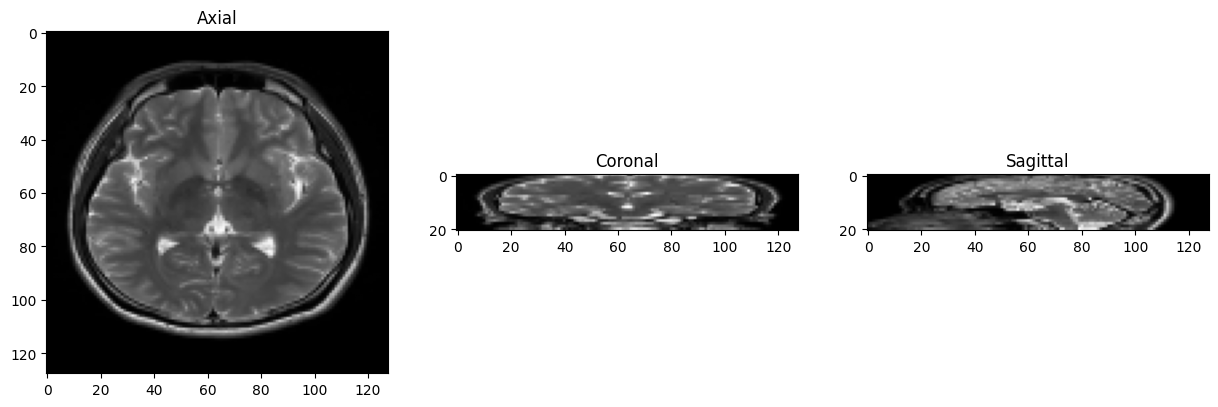

In [7]:
import tempfile
import pathlib
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import shutil
from monai.transforms import ScaleIntensityRange, Resize, Compose

# --- Download real DICOM data ---
dicom_file_url = "https://marketing.webassets.siemens-healthineers.com/9af51e5a5a75528f/915124f7f1b1/IMG-0001-00001.dcm"
dcm_filename = os.path.join(tempfile.gettempdir(), "IMG-0001-00001.dcm")
dicom_base_tmp_dir = tempfile.mkdtemp()
dicom_series_dir = tempfile.mkdtemp(dir=dicom_base_tmp_dir)

print(f"Downloading DICOM file from {dicom_file_url}...")
try:
    response = requests.get(dicom_file_url, stream=True)
    response.raise_for_status()
    with open(dcm_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    shutil.move(dcm_filename, os.path.join(dicom_series_dir, os.path.basename(dcm_filename)))
except Exception as e:
    print(f"Error: {e}. Falling back to dummy data.")
    num_dummy_slices = 10
    for i in range(num_dummy_slices):
        dummy_dcm_path = pathlib.Path(dicom_series_dir) / f"dummy_{i:03d}.dcm"
        ds = pydicom.Dataset()
        ds.SOPClassUID = '1.2.840.10008.5.1.4.1.1.2'
        ds.PixelData = np.random.randint(0, 100, size=(64, 64), dtype=np.uint16).tobytes()
        ds.Rows = 64
        ds.Columns = 64
        ds.BitsAllocated = 16
        ds.SamplesPerPixel = 1
        ds.PhotometricInterpretation = 'MONOCHROME2'
        ds.file_meta = pydicom.FileMetaDataset()
        ds.file_meta.TransferSyntaxUID = pydicom.uid.ImplicitVRLittleEndian
        ds.save_as(str(dummy_dcm_path))

# --- Load and visualize DICOM series ---
dicom_files = sorted([os.path.join(dicom_series_dir, f) for f in os.listdir(dicom_series_dir) if f.endswith('.dcm')])

try:
    if dicom_files:
        # 1. Load slices
        slices = [pydicom.dcmread(f, force=True).pixel_array for f in dicom_files]

        # 2. Stack into (D, H, W)
        dicom_volume_np = np.stack(slices, axis=0).astype(np.float32)

        # 3. Add Channel dimension -> (C, D, H, W) where C=1
        if dicom_volume_np.ndim == 3:
            dicom_volume_np = dicom_volume_np[np.newaxis, ...]

        a_min, a_max = dicom_volume_np.min(), dicom_volume_np.max()
        if a_min == a_max: a_max += 1e-6

        # 4. Define Transform with correct spatial dimensions (D, H, W)
        spatial_size = (dicom_volume_np.shape[1], 128, 128)

        dicom_transform_pipeline = Compose([
            ScaleIntensityRange(a_min=a_min, a_max=a_max, b_min=0.0, b_max=1.0, clip=True),
            Resize(spatial_size=spatial_size)
        ])

        # 5. Apply transform
        dicom_image = dicom_transform_pipeline(dicom_volume_np)

        # 6. Visualize
        plt.figure("DICOM Visualization", (15, 5))
        plt.subplot(1, 3, 1); plt.title("Axial"); plt.imshow(dicom_image[0, dicom_image.shape[1] // 2, :, :], cmap="gray")
        plt.subplot(1, 3, 2); plt.title("Coronal"); plt.imshow(dicom_image[0, :, dicom_image.shape[2] // 2, :], cmap="gray")
        plt.subplot(1, 3, 3); plt.title("Sagittal"); plt.imshow(dicom_image[0, :, :, dicom_image.shape[3] // 2], cmap="gray")
        plt.show()
finally:
    if os.path.exists(dicom_base_tmp_dir):
        shutil.rmtree(dicom_base_tmp_dir)

## Clean Up
Finally, we'll remove the temporary directory and the dummy data we created.

In [ ]:
import shutil
shutil.rmtree(data_dir)
print(f"Cleaned up temporary data directory: {data_dir}")